In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


In [3]:
df = pd.read_csv("../data/productivity_data.csv")

df["date"] = pd.to_datetime(df["date"])

df.head()


,date,hours_worked,focus_hours,meetings,tasks_completed,breaks_taken,productivity_score
0,2026-01-01,8.40,4.64,4,10,2,81.82
1,2026-01-02,7.89,4.43,1,7,9,77.52
2,2026-01-03,8.52,5.98,1,8,5,92.85
3,2026-01-04,9.22,5.28,3,6,10,87.39
4,2026-01-05,7.81,6.21,6,7,5,83.10


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                181 non-null    datetime64[us]
 1   hours_worked        181 non-null    float64       
 2   focus_hours         181 non-null    float64       
 3   meetings            181 non-null    int64         
 4   tasks_completed     181 non-null    int64         
 5   breaks_taken        181 non-null    int64         
 6   productivity_score  181 non-null    float64       
dtypes: datetime64[us](1), float64(3), int64(3)
memory usage: 10.0 KB


In [5]:
df.isnull().sum()


date                  0
hours_worked          0
focus_hours           0
meetings              0
tasks_completed       0
breaks_taken          0
productivity_score    0
dtype: int64

In [6]:
df.describe().round(2)


,date,hours_worked,focus_hours,meetings,tasks_completed,breaks_taken,productivity_score
count,181,181.00,181.00,181.00,181.00,181.00,181.00
mean,2026-04-01 00:00:00,8.01,5.49,2.99,7.86,3.96,87.99
min,2026-01-01 00:00:00,4.00,1.00,0.00,2.00,0.00,59.85
25%,2026-02-15 00:00:00,7.48,4.84,2.00,6.00,3.00,81.82
50%,2026-04-01 00:00:00,8.01,5.56,3.00,8.00,4.00,88.88
75%,2026-05-16 00:00:00,8.49,6.13,4.00,10.00,5.00,94.34
max,2026-06-30 00:00:00,12.00,8.00,9.00,18.00,10.00,100.00
std,NaN,0.89,1.02,1.88,2.79,2.14,8.70


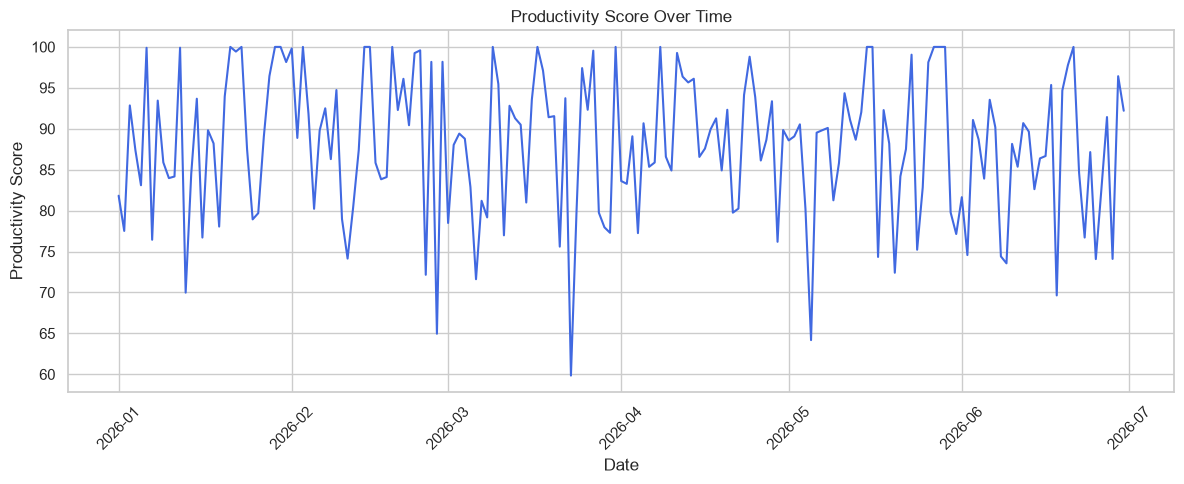

In [7]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["date"],
    df["productivity_score"],
    color="royalblue"
)

plt.title("Productivity Score Over Time")
plt.xlabel("Date")
plt.ylabel("Productivity Score")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


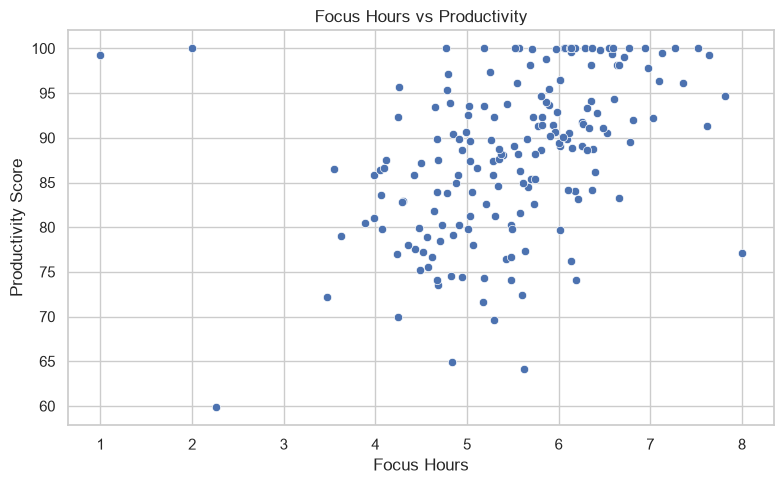

In [8]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="focus_hours",
    y="productivity_score"
)

plt.title("Focus Hours vs Productivity")
plt.xlabel("Focus Hours")
plt.ylabel("Productivity Score")

plt.tight_layout()
plt.show()


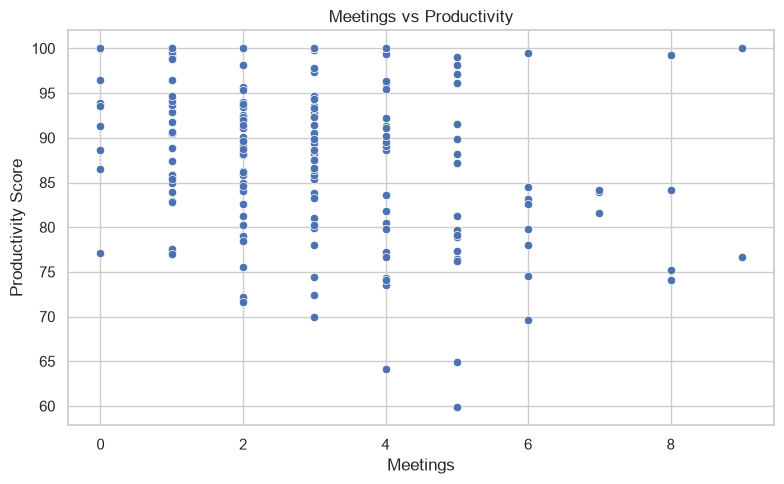

In [9]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="meetings",
    y="productivity_score"
)

plt.title("Meetings vs Productivity")
plt.xlabel("Meetings")
plt.ylabel("Productivity Score")

plt.tight_layout()
plt.show()


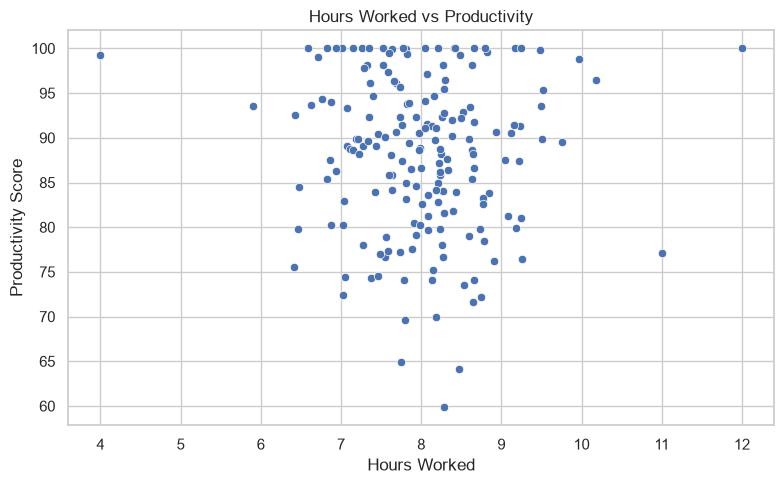

In [10]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="hours_worked",
    y="productivity_score"
)

plt.title("Hours Worked vs Productivity")
plt.xlabel("Hours Worked")
plt.ylabel("Productivity Score")

plt.tight_layout()
plt.show()


In [11]:
correlation = df.select_dtypes("number").corr()["productivity_score"].sort_values(
    ascending=False
)

correlation


productivity_score    1.000000
focus_hours           0.417002
tasks_completed       0.329354
breaks_taken          0.061943
hours_worked         -0.040992
meetings             -0.302803
Name: productivity_score, dtype: float64

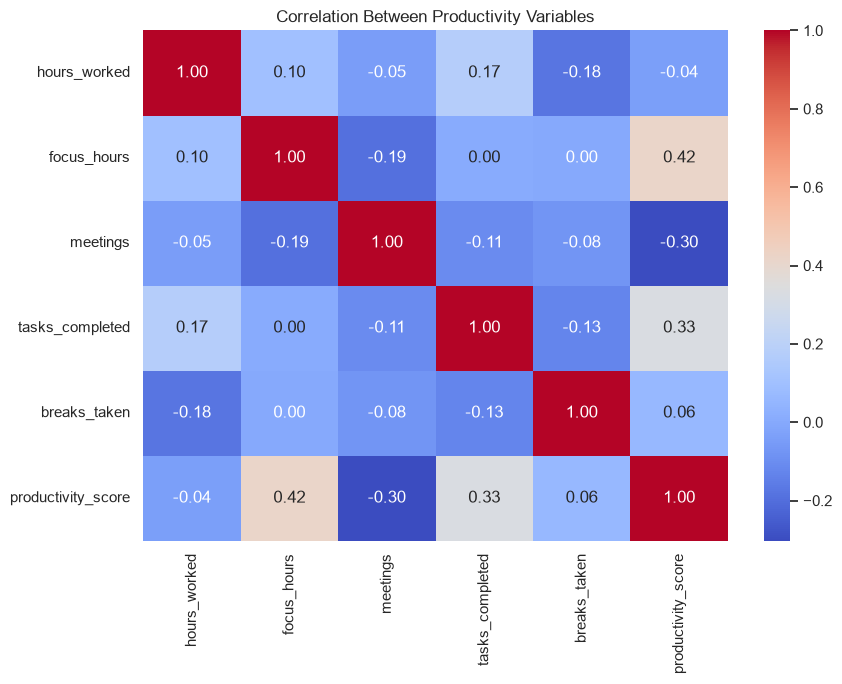

In [12]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    df.select_dtypes("number").corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Productivity Variables")
plt.tight_layout()
plt.show()
